Dữ liệu gốc: (160, 908) (900+ đặc trưng)

--- BƯỚC 1: LỌC NHIỄU (SelectFromModel) ---
=> Đã giảm xuống còn: 313 đặc trưng tinh túy nhất.

--- BƯỚC 2: CHUẨN HÓA DỮ LIỆU (Scaling) ---

--- BẮT ĐẦU CHẠY 5-FOLD CHI TIẾT ---
Fold  | Accuracy   | F1-Score   | AUC       
---------------------------------------------
1     | 75.00%     | 0.7647     | 0.8320
2     | 81.25%     | 0.7692     | 0.8516
3     | 87.50%     | 0.8750     | 0.8945
4     | 78.12%     | 0.7879     | 0.8672
5     | 78.12%     | 0.7407     | 0.8281


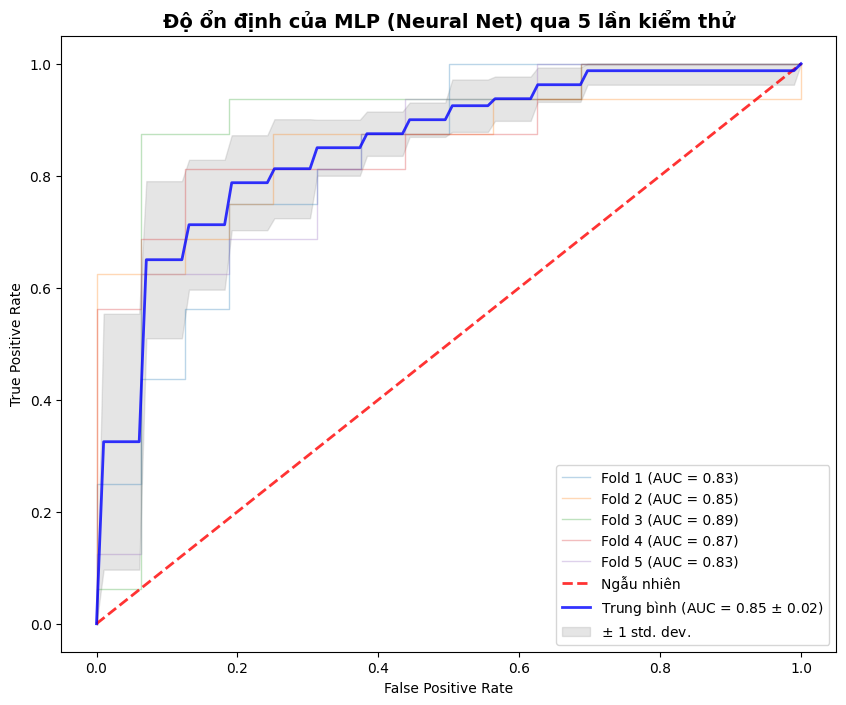


 KẾT QUẢ CUỐI CÙNG (NEURAL NETWORK MLP)
Độ chính xác trung bình: 80.00% (+/- 4.24%)
AUC trung bình:          0.8521


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, f1_score
import warnings

warnings.filterwarnings("ignore")

file_path = 'eye_tracking_features_k30_graph.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['label', 'numeric_id'])
y = df['label']

print(f"Dữ liệu gốc: {X.shape} (900+ đặc trưng)")
print("\n--- BƯỚC 1: LỌC NHIỄU (SelectFromModel) ---")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X, y)
print(f"=> Đã giảm xuống còn: {X_selected.shape[1]} đặc trưng tinh túy nhất.")

# BƯỚC B: CHUẨN HÓA (STANDARD SCALER)
# Mạng Neron bắt buộc phải có bước này mới hội tụ được
print("\n--- BƯỚC 2: CHUẨN HÓA DỮ LIỆU (Scaling) ---")
scaler = StandardScaler()
X_final = scaler.fit_transform(X_selected)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cấu hình MLP y hệt trong danh sách models cũ
# ('Neural Net (MLP)', MLPClassifier(max_iter=1000, random_state=42))
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Biến lưu kết quả để vẽ
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
accuracies = []
f1_scores = []

plt.figure(figsize=(10, 8))

print("\n--- BẮT ĐẦU CHẠY 5-FOLD CHI TIẾT ---")
print(f"{'Fold':<5} | {'Accuracy':<10} | {'F1-Score':<10} | {'AUC':<10}")
print("-" * 45)

for i, (train_idx, test_idx) in enumerate(cv.split(X_final, y)):
    # Chia dữ liệu (Dùng X_final đã qua xử lý)
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Huấn luyện
    mlp.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = mlp.predict(X_test)
    y_prob = mlp.predict_proba(X_test)[:, 1]
    
    # Tính chỉ số
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Lưu lại
    accuracies.append(acc)
    f1_scores.append(f1)
    aucs.append(roc_auc)
    
    # Vẽ đường ROC mờ cho fold này
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.2f})')
    
    # Nội suy để tính trung bình
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    print(f"{i+1:<5} | {acc*100:.2f}%     | {f1:.4f}     | {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Ngẫu nhiên', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vẽ đường trung bình
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Trung bình (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2, alpha=.8)

# Vẽ vùng sai số (Standard Deviation)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Độ ổn định của MLP (Neural Net) qua 5 lần kiểm thử', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# IN KẾT QUẢ TỔNG HỢP
print("\n" + "="*40)
print(" KẾT QUẢ CUỐI CÙNG (NEURAL NETWORK MLP)")
print("="*40)
print(f"Độ chính xác trung bình: {np.mean(accuracies)*100:.2f}% (+/- {np.std(accuracies)*100:.2f}%)")
print(f"AUC trung bình:          {mean_auc:.4f}")
print("="*40)

--- ĐANG ĐỌC DỮ LIỆU: eye_tracking_features_k30_graph.csv ---

--- BẮT ĐẦU DÒ TÌM SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU ---
Số Feature      | Accuracy (GB)       
----------------------------------------
10              | 68.75%
30              | 69.38%
50              | 69.38%
80              | 73.75%
100             | 74.38%
130             | 66.88%
160             | 70.00%
200             | 70.00%
250             | 68.75%
300             | 73.12%
400             | 72.50%
500             | 73.75%
700             | 73.12%
908             | 73.75%

 SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU NHẤT: 100 Features
   Độ chính xác tương ứng: 74.38%


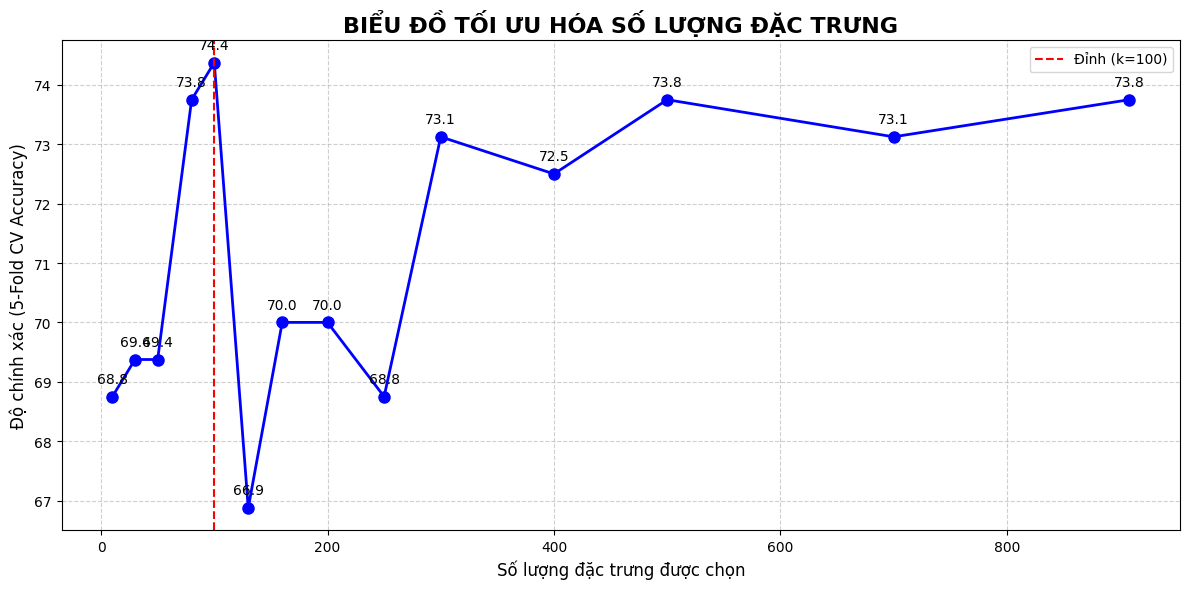

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# 1. ĐỌC DỮ LIỆU
file_path = 'eye_tracking_features_k30_graph.csv'
print(f"--- ĐANG ĐỌC DỮ LIỆU: {file_path} ---")
df = pd.read_csv(file_path)
X = df.drop(columns=['label', 'numeric_id'])
y = df['label']

# 2. THIẾT LẬP DẢI ĐẶC TRƯNG CẦN TEST
# Chúng ta sẽ thử các mốc: 10, 30, 50, ..., 908
k_values = [10, 30, 50, 80, 100, 130, 160, 200, 250, 300, 400, 500, 700, X.shape[1]]
results = []

print("\n--- BẮT ĐẦU DÒ TÌM SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU ---")
print(f"{'Số Feature':<15} | {'Accuracy (GB)':<20}")
print("-" * 40)

# Sử dụng Gradient Boosting làm thước đo (vì nó là model mạnh nhất của bạn)
# Bạn có thể thay bằng MLPClassifier nếu muốn đo cho Neural Net
clf = GradientBoostingClassifier(n_estimators=200, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    try:
        # Pipeline: Lọc k đặc trưng -> Chuẩn hóa -> Train
        # threshold=-np.inf và max_features=k để ép lấy đúng k đặc trưng
        pipeline = Pipeline([
            ('selector', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold=-np.inf, max_features=k)),
            ('scaler', StandardScaler()),
            ('classifier', clf)
        ])
        
        # Chạy 5-Fold
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
        acc_mean = scores.mean() * 100
        
        results.append(acc_mean)
        print(f"{k:<15} | {acc_mean:.2f}%")
        
    except Exception as e:
        print(f"{k:<15} | Lỗi: {e}")
        results.append(0)

# 3. TÌM RA CON SỐ VÀNG
best_idx = np.argmax(results)
best_k = k_values[best_idx]
best_score = results[best_idx]

print("\n" + "="*50)
print(f" SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU NHẤT: {best_k} Features")
print(f"   Độ chính xác tương ứng: {best_score:.2f}%")
print("="*50)

# 4. VẼ BIỂU ĐỒ TRỰC QUAN
plt.figure(figsize=(12, 6))
plt.plot(k_values, results, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Đỉnh (k={best_k})')

# Trang trí
plt.title('BIỂU ĐỒ TỐI ƯU HÓA SỐ LƯỢNG ĐẶC TRƯNG', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng đặc trưng được chọn', fontsize=12)
plt.ylabel('Độ chính xác (5-Fold CV Accuracy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Hiển thị số liệu lên biểu đồ
for i, txt in enumerate(results):
    plt.annotate(f"{txt:.1f}", (k_values[i], results[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()